In [14]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import seaborn as sns
from prophet.diagnostics import cross_validation, performance_metrics
import itertools

In [15]:
df = pd.read_parquet('../data/processed/preprocessed_prophet.parquet')
df.dropna(inplace = True)
df.head()

,mempool_blocks_blockSize,mempool_blocks_blockVSize,mempool_blocks_nTx,mempool_blocks_totalFees,mempool_blocks_medianFee,recommended_fee_fastestFee,recommended_fee_halfHourFee,recommended_fee_hourFee,recommended_fee_economyFee,recommended_fee_minimumFee,...,mempool_fee_histogram_bin_70_75,mempool_fee_histogram_bin_75_80,mempool_fee_histogram_bin_80_85,mempool_fee_histogram_bin_85_90,mempool_fee_histogram_bin_90_95,mempool_fee_histogram_bin_95_100,mempool_fee_histogram_bin_100_150,mempool_fee_histogram_bin_150_200,mempool_fee_histogram_bin_200_250,mempool_fee_histogram_bin_250_300
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-03-05 02:00:00,2.131827e+06,997874.250000,1030.000000,2.077770e+06,1.300139,2.000000,2.000000,2.000000,2.000000,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-05 02:15:00,1.801526e+06,997925.916667,2627.000000,3.407913e+06,2.473960,3.000000,2.666667,2.666667,2.666667,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-05 02:30:00,2.055350e+06,997965.916667,922.000000,1.855358e+06,1.355898,2.000000,2.000000,2.000000,2.000000,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-05 02:45:00,2.006800e+06,997970.083333,1296.666667,2.167251e+06,1.536092,2.333333,2.333333,2.333333,2.333333,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-05 03:00:00,1.773658e+06,997960.333333,2725.333333,3.462741e+06,2.467659,3.333333,3.000000,3.000000,3.000000,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
y = df["recommended_fee_fastestFee"]
X = df.drop(columns = "recommended_fee_fastestFee")
X = X.reset_index()
X = X.drop(columns = "timestamp")

# last 24h as test
split_index = len(X) - 96

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [17]:
df_prophet = y_train.reset_index()
df_prophet = df_prophet.rename(columns={
    'timestamp': 'ds',
    'recommended_fee_fastestFee': 'y'
})
df_prophet['y'] = np.log1p(df_prophet['y'])
df_prophet.head()

,ds,y
0,2025-03-05 02:00:00,1.098612
1,2025-03-05 02:15:00,1.386294
2,2025-03-05 02:30:00,1.098612
3,2025-03-05 02:45:00,1.203973
4,2025-03-05 03:00:00,1.466337


In [6]:
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False
)
model.add_seasonality(name='hourly', period=1/24, fourier_order=5) # 每小时重复（注意 period 是 1/24）
model.add_seasonality(name='hourly', period=1, fourier_order=10)  # 每小时周期
model.add_seasonality(name='daily', period=24, fourier_order=5)  # 每日周期

In [7]:
param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 0.3, 0.5],
    'seasonality_prior_scale': [5.0, 10.0, 20.0],
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_range': [0.8, 0.9, 0.95],
    'n_changepoints': [25, 50, 100]
}

In [8]:
import logging
logging.getLogger("prophet").setLevel(logging.ERROR)
# 创建参数组合
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

results = []  # 存放每组评估结果

for params in all_params:
    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        **params
    )
    m.add_seasonality(name='hourly', period=1/24, fourier_order=6)
    m.add_seasonality(name='daily', period=1, fourier_order=8)
    m.add_seasonality(name='weekly', period=7, fourier_order=4)
    
    m.fit(df_prophet)
    df_cv = cross_validation(m, initial='7 days', period='1 day', horizon='1 day', parallel="processes")
    df_p = performance_metrics(df_cv)
    
    results.append((params, df_p['rmse'].mean()))
print("Done")

21:23:38 - cmdstanpy - INFO - Chain [1] start processing
21:23:39 - cmdstanpy - INFO - Chain [1] done processing
21:23:40 - cmdstanpy - INFO - Chain [1] start processing
21:23:40 - cmdstanpy - INFO - Chain [1] start processing
21:23:40 - cmdstanpy - INFO - Chain [1] start processing
21:23:41 - cmdstanpy - INFO - Chain [1] start processing
21:23:41 - cmdstanpy - INFO - Chain [1] start processing
21:23:41 - cmdstanpy - INFO - Chain [1] done processing
21:23:41 - cmdstanpy - INFO - Chain [1] start processing
21:23:41 - cmdstanpy - INFO - Chain [1] done processing
21:23:41 - cmdstanpy - INFO - Chain [1] done processing
21:23:41 - cmdstanpy - INFO - Chain [1] start processing
21:23:41 - cmdstanpy - INFO - Chain [1] done processing
21:23:41 - cmdstanpy - INFO - Chain [1] start processing
21:23:41 - cmdstanpy - INFO - Chain [1] start processing
21:23:41 - cmdstanpy - INFO - Chain [1] done processing
21:23:41 - cmdstanpy - INFO - Chain [1] start processing
21:23:41 - cmdstanpy - INFO - Chain [

Done


22:20:11 - cmdstanpy - INFO - Chain [1] done processing
22:20:12 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
best_params = sorted(results, key=lambda x: x[1])[0]
print(f"最优参数组合：{best_params[0]}\n对应RMSE：{best_params[1]:.4f}")

最优参数组合：{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 20.0, 'seasonality_mode': 'additive', 'changepoint_range': 0.8, 'n_changepoints': 25}
对应RMSE：0.3541


In [39]:
def get_result(df):
    df.index = y.index
    y_pred = df.iloc[-96:]
    y_pred = np.expm1(y_pred["yhat"])
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}")
    result_df = pd.DataFrame({
        'Actual': y,
        'Predicted': y_pred
    }, index=y.index)

    plt.figure(figsize=(14, 5))
    sns.lineplot(data=result_df)
    plt.title('Predicted vs Actual Fee Rates')
    plt.xlabel('Time (sample index)')
    plt.ylabel('Fee rate (sats/vByte)')
    plt.legend(['Actual', 'Predicted'])
    plt.tight_layout()
    plt.show()

In [30]:
def create_model():
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        changepoint_prior_scale = 0.1,
        seasonality_prior_scale=20.0,
        seasonality_mode='additive',
        changepoint_range=0.8,
        n_changepoints=25
    )
    model.add_seasonality(name='hourly', period=1/24, fourier_order=5) # 每小时重复（注意 period 是 1/24）
    model.add_seasonality(name='daily', period=1, fourier_order=10)  # 每小时周期
    model.add_seasonality(name='weekly', period=24, fourier_order=5)  # 每日周期
    return model

In [31]:
model = create_model()
model.fit(df_prophet)

13:01:18 - cmdstanpy - INFO - Chain [1] start processing
13:01:19 - cmdstanpy - INFO - Chain [1] done processing


In [32]:
future = model.make_future_dataframe(periods=96, freq='15min')

In [33]:
forecast = model.predict(future)

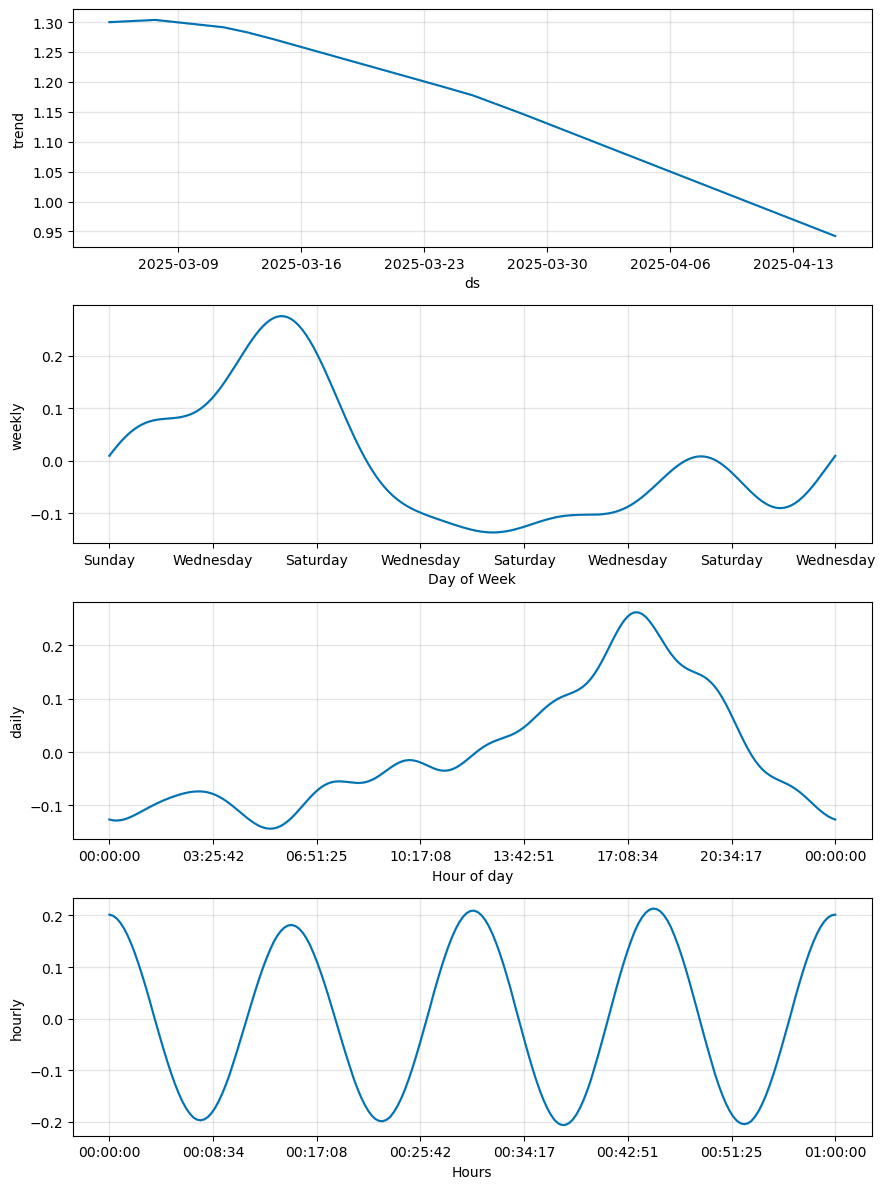

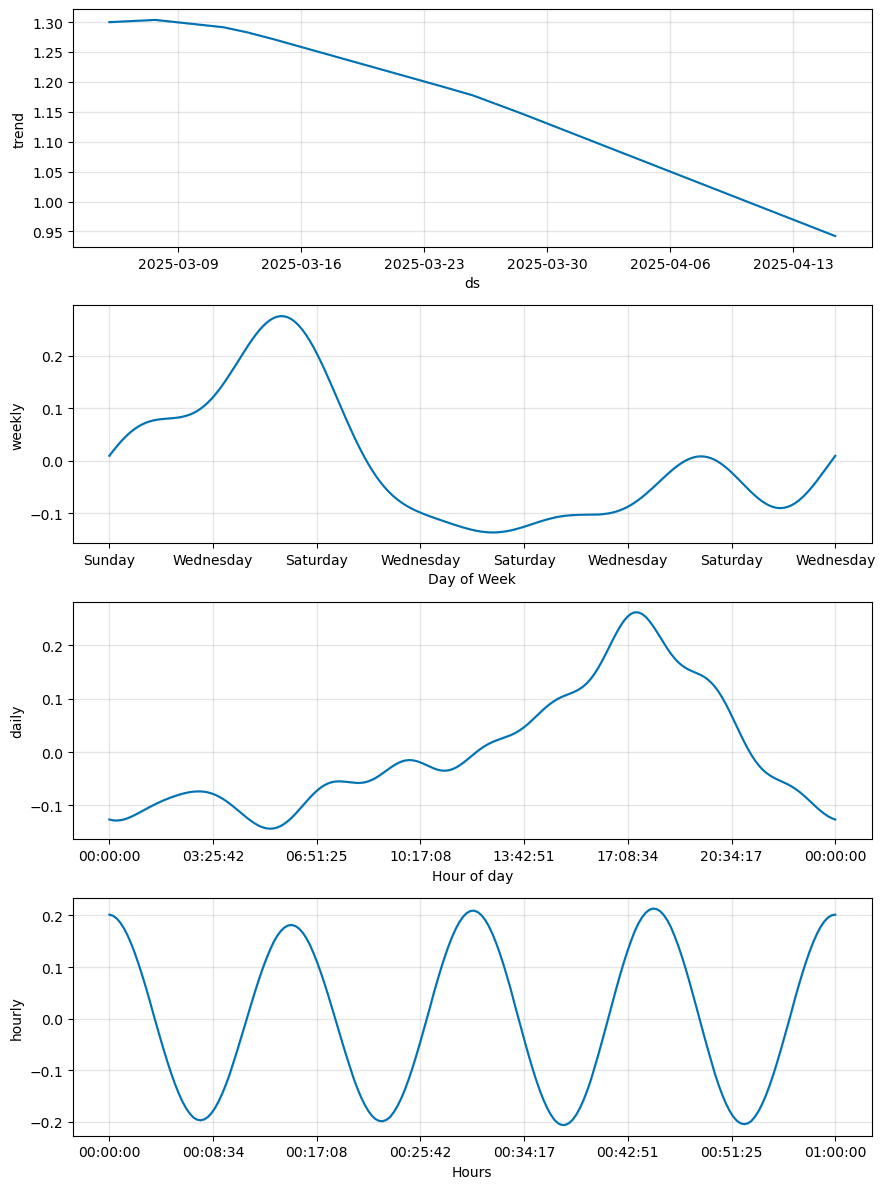

In [34]:
model.plot_components(forecast)

MAE: 1.2226
RMSE: 1.6825
MAPE: 0.4671


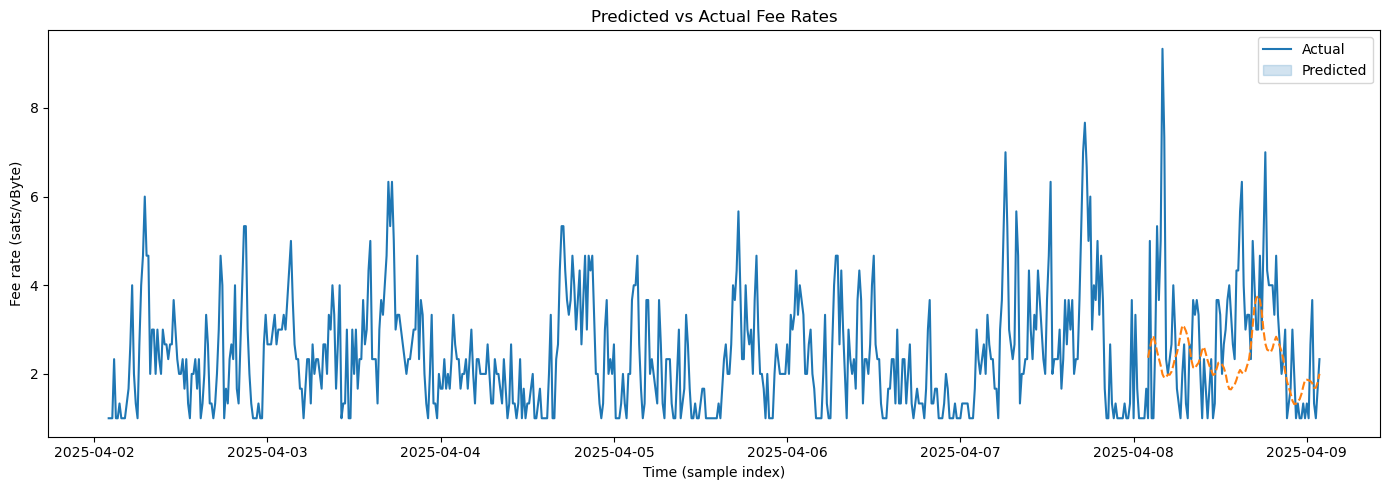

In [40]:
get_result(forecast)

13:18:43 - cmdstanpy - INFO - Chain [1] start processing
13:18:43 - cmdstanpy - INFO - Chain [1] done processing


Week 1
MAE: 2.4674
RMSE: 3.5025
MAPE: 0.5546


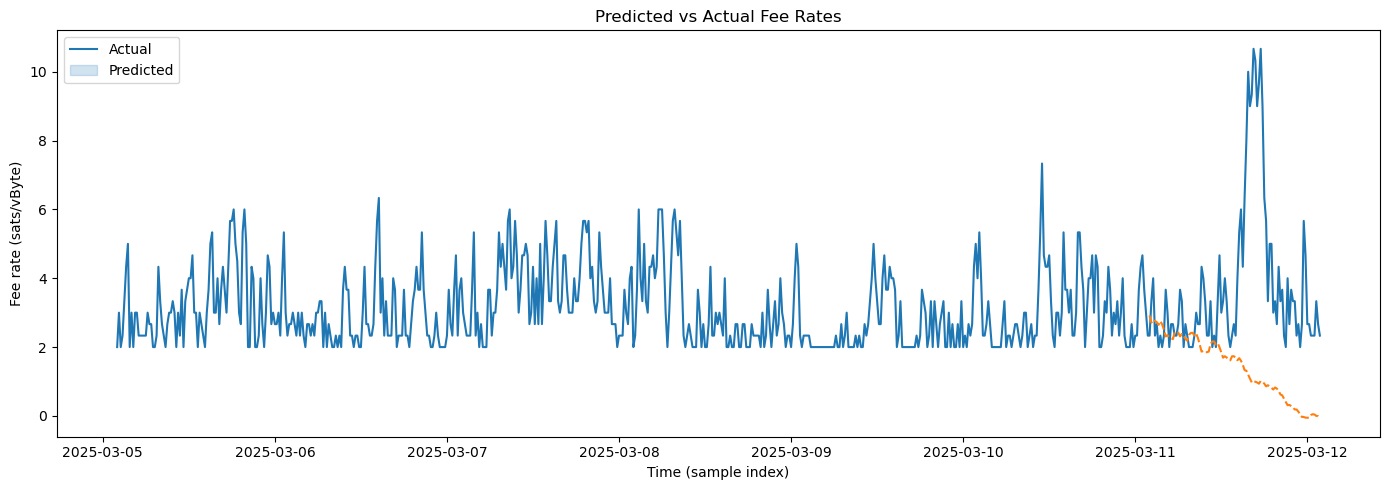

13:18:44 - cmdstanpy - INFO - Chain [1] start processing
13:18:44 - cmdstanpy - INFO - Chain [1] done processing


Week 2
MAE: 0.6801
RMSE: 0.9296
MAPE: 0.2324


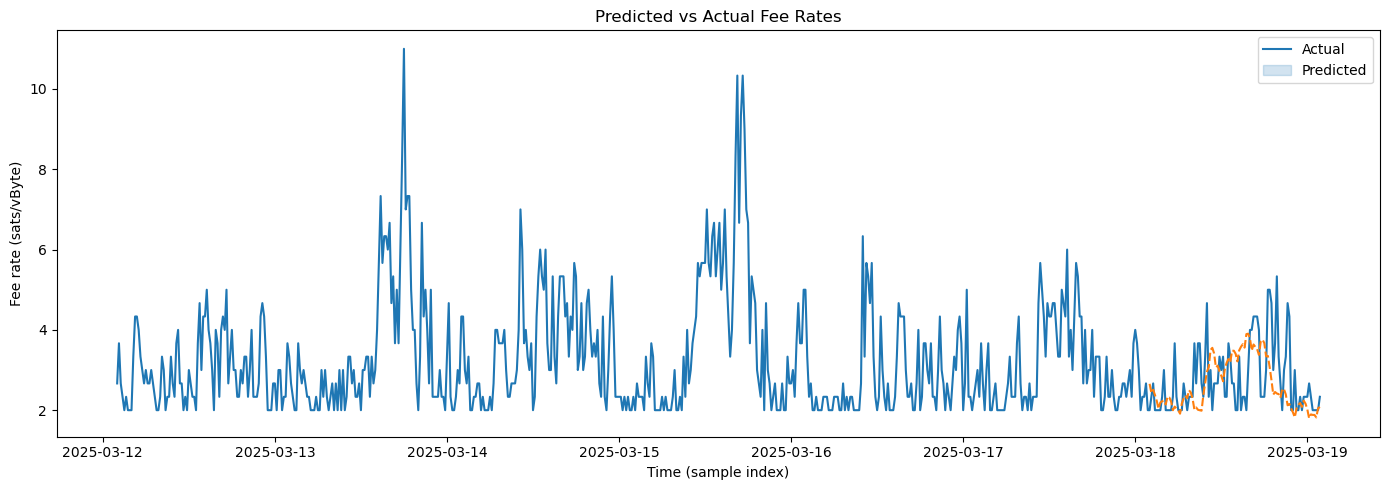

Week 3


13:18:44 - cmdstanpy - INFO - Chain [1] start processing
13:18:44 - cmdstanpy - INFO - Chain [1] done processing


MAE: 5.5266
RMSE: 8.2646
MAPE: 1.0230


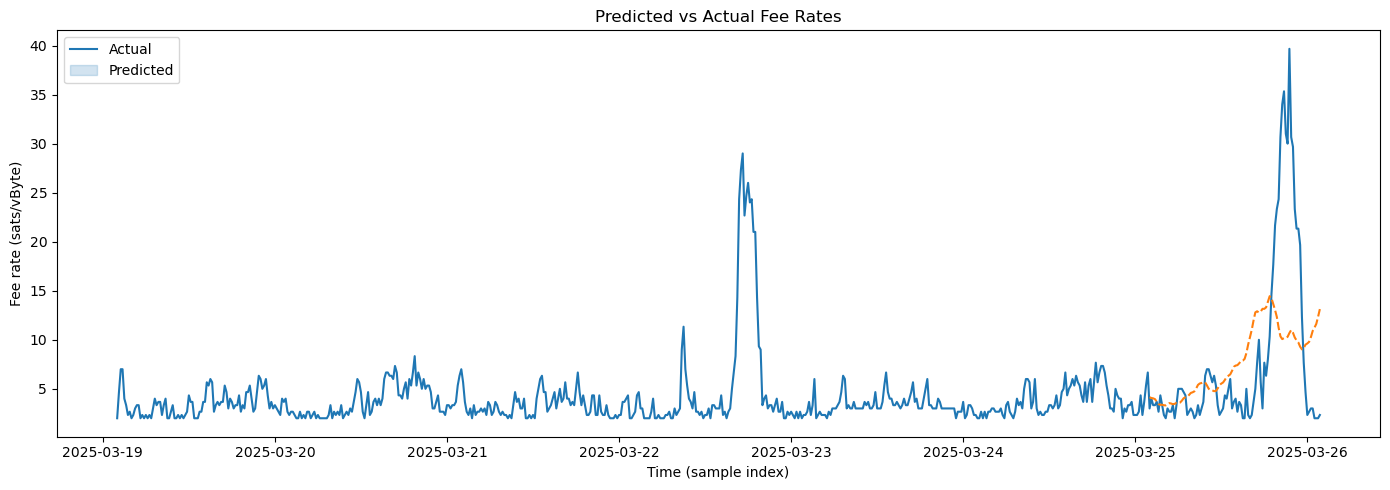

13:18:44 - cmdstanpy - INFO - Chain [1] start processing


Week 4


13:18:44 - cmdstanpy - INFO - Chain [1] done processing


MAE: 0.9046
RMSE: 1.1421
MAPE: 0.4880


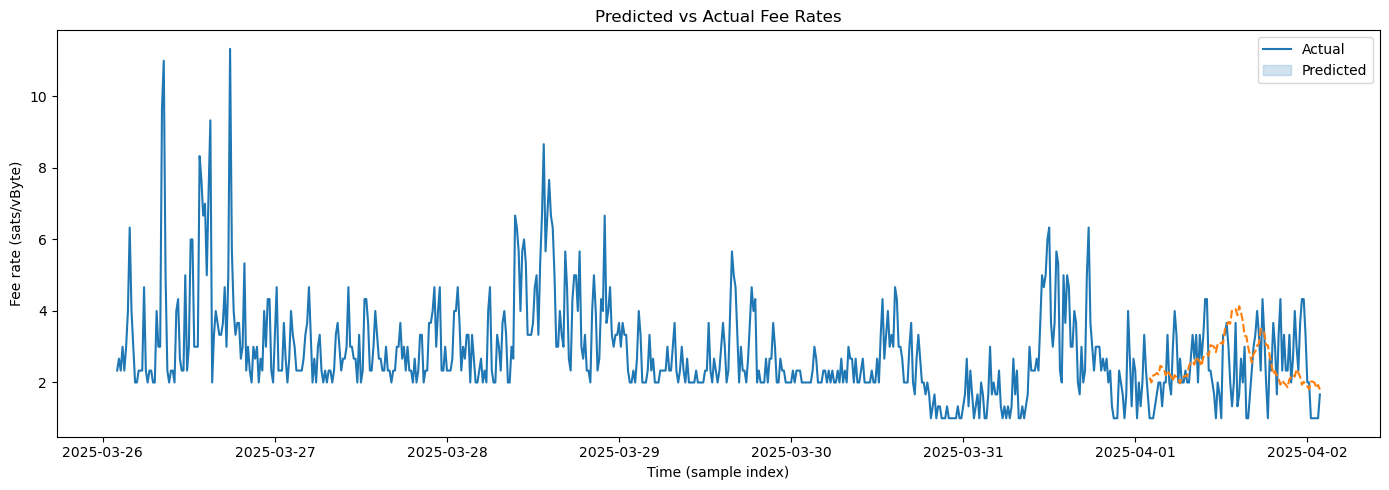

Week 5


13:18:44 - cmdstanpy - INFO - Chain [1] start processing
13:18:44 - cmdstanpy - INFO - Chain [1] done processing


MAE: 1.2226
RMSE: 1.6825
MAPE: 0.4671


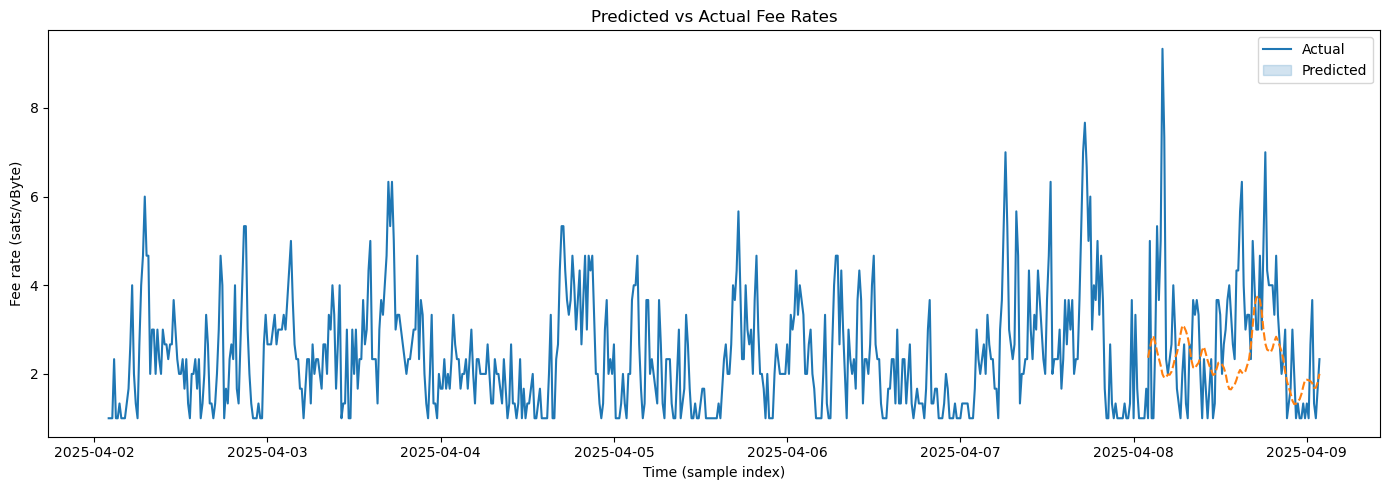

In [41]:
for i in range(5):
    print("Week",(i+1))
    df_sliding = df[0+i*7*96:7*96+i*7*96]
    y = df_sliding["recommended_fee_fastestFee"]
    split_index = len(y) - 96
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
    df_prophet = y_train.reset_index()
    df_prophet = df_prophet.rename(columns={
        'timestamp': 'ds',
        'recommended_fee_fastestFee': 'y'
    })
    df_prophet['y'] = np.log1p(df_prophet['y'])

    model = create_model()
    model.fit(df_prophet)
    future = model.make_future_dataframe(periods=96, freq='15min')
    forecast = model.predict(future)
    get_result(forecast)